# Per-Bone Ground-Truth Build & Alignment

Voxelize manual Slicer STLs (femur/tibia/patella/fibula) onto each case's predrr grid,
write per-bone `.nii.gz` for Slicer inspection, and validate alignment before modelling.

In [1]:
from pathlib import Path
import re, numpy as np, nibabel as nib, trimesh
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

BONES = ["femur", "tibia", "patella", "fibula"]
STL_ROOT  = ROOT / "data/external/ground_truth/fracture_ground_truth"
PREDRR    = ROOT / "data/interim/predrr/fractured"
OUT_ROOT  = ROOT / "data/interim/gt_per_bone_256/fractured"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# folder-stem (Case<N>) -> predrr KEY (side comes from predrr, not the STL token)
CASE_TO_KEY = {p.name.split("_Part")[0]: p.stem.replace(".nii", "")
               for p in PREDRR.glob("*.nii.gz")}
print("predrr keys:", sorted(CASE_TO_KEY.values()))

predrr keys: ['Case11_PartRight', 'Case12_PartRight', 'Case13_PartRight', 'Case14_PartRight', 'Case15_PartRight', 'Case16_PartRight', 'Case1_PartLeft', 'Case2_PartLeft', 'Case3_PartLeft', 'Case5_PartRight', 'Case6_PartRight', 'Case7_PartRight', 'Case9_PartRight']


In [2]:
def parse_bone(fname: str) -> str:
    """Map a messy STL filename to one of BONES by substring, ignoring side/segmentation noise."""
    s = fname.lower()
    for bone in BONES:
        if bone in s:                  # 'femur','tibia','patella','fibula'
            return bone
    raise ValueError(f"no bone token in {fname!r}")

In [3]:
def _case_stem(folder_name: str) -> str:
    # "Case2 (does not seem fractured)" -> "Case2" ; "Case11" -> "Case11"
    return re.match(r"(Case\d+)", folder_name).group(1)

cases = {}
for folder in sorted(STL_ROOT.iterdir()):
    if not folder.is_dir():
        continue
    stem = _case_stem(folder.name)
    if stem not in CASE_TO_KEY:        # e.g. no predrr -> skip
        print("SKIP (no predrr):", folder.name); continue
    bone_map = {}
    for stl in folder.glob("*.stl"):
        bone = parse_bone(stl.name)
        assert bone in BONES, f"bad bone {bone} for {stl.name}"
        assert bone not in bone_map, f"duplicate {bone} in {folder.name}: {stl.name} vs {bone_map[bone].name}"
        bone_map[bone] = stl
    missing = set(BONES) - set(bone_map)
    print(f"{folder.name:45s} -> {CASE_TO_KEY[stem]:18s} bones={sorted(bone_map)} missing={sorted(missing)}")
    cases[CASE_TO_KEY[stem]] = bone_map
assert cases, "no cases mapped"

Case1                                         -> Case1_PartLeft     bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]
Case11                                        -> Case11_PartRight   bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]
Case12                                        -> Case12_PartRight   bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]
Case13                                        -> Case13_PartRight   bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]
Case16                                        -> Case16_PartRight   bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]
Case2 (does not seem fractured)               -> Case2_PartLeft     bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]
Case3                                         -> Case3_PartLeft     bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]
Case5                                         -> Case5_PartRight    bones=['femur', 'fibula', 'patella', 'tibia'] missing=[]


## Replay predrr's Geometric Transform (ported VERBATIM from `predrr_preprocessing.ipynb`)

The predrr `.nii.gz` volumes were written with a zeroed-translation affine — their world
coordinates are gone. The raw fractured CTs still carry the original world frame shared by the
manual Slicer STLs, so instead of using predrr's affine we **replay the exact same
load → resample → orient → window → crop → FOV → resize → S-I-flip pipeline** on the raw CT.
If the replay is faithful, it reproduces the stored predrr array exactly (mod orientation
flip), and the *same* crop/FOV/resize geometry can then be applied to each STL-derived bone
label so it lands aligned on the predrr grid by construction.

Constants, `correct_orientation` family, and pipeline helpers below are copied verbatim from
`notebooks/pre-processing/predrr_preprocessing.ipynb` (cells 1, 3, 6). That notebook is not
modified.

In [4]:
import SimpleITK as sitk
from scipy import ndimage

# ============================================================
# Constants — ported VERBATIM from predrr_preprocessing.ipynb CELL 1
# ============================================================
TARGET_SIZE = 256               # voxels per axis (config-driven: 128 local / 512 HPC)
RESAMPLE_SPACING = 0.5          # mm, isotropic resampling target
ORIENTATION = "RAS"             # Right-Anterior-Superior (confirmed param)

FOV_MM = 200.0                  # physical cube side (mm)
FOV_VOXELS = int(round(FOV_MM / RESAMPLE_SPACING))   # cube side in voxels @ resample spacing (=400)

HU_MIN = -450
HU_MAX = 1050

ROI_INTENSITY_THRESHOLD = 0.1   # fraction of normalized range
ROI_CLOSING_RADIUS = 3          # morphological closing ball radius (voxels)
ROI_PAD_MARGIN = 5              # padding voxels around bounding box


# ============================================================
# Orientation Correction — S-I upright (femur on top) — ported VERBATIM from CELL 3
# ============================================================
BONE_THR = 0.45    # normalized-intensity threshold for "bone"
MIN_AREA = 30      # min voxels for a 2D component to count as a blob
END_FRAC = 0.25    # use the top/bottom quarter of the S-I axis as the two ends

SI_FLIP_OVERRIDE = {
    "VSD_016_Left": False,
    "VSD_016_Right": False,
    "Case14_PartRight": False,
    "Case3_PartLeft": False,
}


def _blobs_in_axial(sl2d):
    """Number of bone components (area > MIN_AREA) in one (y, x) axial slice."""
    mask = ndimage.binary_opening(sl2d > BONE_THR, iterations=1)
    lab, n = ndimage.label(mask)
    if n == 0:
        return 0
    sizes = ndimage.sum(np.ones_like(lab), lab, range(1, n + 1))
    return int((sizes > MIN_AREA).sum())


def end_blob_counts(arr):
    """Median axial blob count at the superior (high axis-0) and inferior (low axis-0) ends."""
    k = arr.shape[0]
    e = max(1, int(round(k * END_FRAC)))
    sup = float(np.median([_blobs_in_axial(arr[kk]) for kk in range(k - e, k)]))
    inf = float(np.median([_blobs_in_axial(arr[kk]) for kk in range(0, e)]))
    return sup, inf


def heuristic_flipped(arr):
    """True only when the volume is confidently upside-down (superior end >=2, inferior <=1)."""
    sup, inf = end_blob_counts(arr)
    return sup >= 2 and inf <= 1


def correct_orientation(vid, arr):
    """Flip the volume S-I upright if needed. Returns (arr, flags).

    Decision: SI_FLIP_OVERRIDE[vid] if pinned, else the live heuristic on this raw-derived array.
    """
    flip_si = SI_FLIP_OVERRIDE.get(vid, heuristic_flipped(arr))
    if flip_si:
        arr = np.ascontiguousarray(np.flip(arr, axis=0))
    return arr, {"si_flipped": bool(flip_si)}


# ============================================================
# Pipeline Helper Functions — ported VERBATIM from CELL 6
# ============================================================

def resample_volume(sitk_img, new_spacing=(RESAMPLE_SPACING,)*3):
    """Resample a SimpleITK image to isotropic spacing."""
    original_spacing = sitk_img.GetSpacing()
    original_size = sitk_img.GetSize()

    new_size = [
        int(round(osz * osp / nsp))
        for osz, osp, nsp in zip(original_size, original_spacing, new_spacing)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_img.GetDirection())
    resampler.SetOutputOrigin(sitk_img.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(float(sitk.GetArrayViewFromImage(sitk_img).min()))
    resampler.SetInterpolator(sitk.sitkLinear)
    return resampler.Execute(sitk_img)


def orient_volume(sitk_img, orientation=ORIENTATION):
    """Reorient a SimpleITK image to the target orientation."""
    orienter = sitk.DICOMOrientImageFilter()
    orienter.SetDesiredCoordinateOrientation(orientation)
    return orienter.Execute(sitk_img)


def apply_bone_window(arr, hu_min=HU_MIN, hu_max=HU_MAX):
    """Clip to bone window and normalize to [0, 1]."""
    arr = np.clip(arr, hu_min, hu_max)
    arr = (arr - hu_min) / (hu_max - hu_min)
    return arr.astype(np.float32)


def body_envelope_mask(arr_windowed, soft_thr=ROI_INTENSITY_THRESHOLD, open_iter=1):
    """Zero everything outside the limb. The CT table/support slab is separated from the leg by
    an air gap, so at a soft-tissue threshold it forms a separate connected component; keeping
    the largest component (+ fill holes) drops the slab while preserving bone, soft tissue and
    any displaced fracture fragment inside the skin envelope. Orientation-agnostic."""
    body = arr_windowed > soft_thr
    struct = ndimage.generate_binary_structure(3, 1)
    body = ndimage.binary_opening(body, struct, iterations=open_iter)
    labeled, n = ndimage.label(body)
    if n == 0:
        return arr_windowed
    sizes = ndimage.sum(np.ones_like(labeled), labeled, range(1, n + 1))
    keep = ndimage.binary_fill_holes(labeled == (np.argmax(sizes) + 1))
    return np.where(keep, arr_windowed, 0.0).astype(np.float32)


def center_to_fixed_fov(arr, fov_voxels=FOV_VOXELS, fill_value=0.0):
    """
    Place the (bone-tight) ROI crop, CENTERED, into a fixed cubic box of side `fov_voxels`.

    This replaces the old pad_to_cube (which sized the cube to the longest crop axis and so
    produced a different physical FOV / spacing per volume). With a FIXED box:
      - axes SHORTER than fov_voxels are center-padded with `fill_value` (black)
      - axes LONGER  than fov_voxels are center-cropped (excess anatomy trimmed)
    => every volume shares the same physical FOV and (after resize) the same mm/voxel.

    Centering uses the array center, which equals the ROI-crop center (roi_bone_crop already
    tightened the box around the largest bone component).

    Returns: (fixed_box_array, clipped_flags) where clipped_flags = (clip_z, clip_y, clip_x),
    each True if that axis was longer than fov_voxels (i.e. anatomy was trimmed).
    """
    out = np.full((fov_voxels, fov_voxels, fov_voxels), fill_value, dtype=arr.dtype)
    clipped = [False, False, False]

    src_slices, dst_slices = [], []
    for axis, n in enumerate(arr.shape):
        if n <= fov_voxels:
            # center-pad: full source fits, place it centered in the box
            start = (fov_voxels - n) // 2
            src_slices.append(slice(0, n))
            dst_slices.append(slice(start, start + n))
        else:
            # center-crop: take the central fov_voxels of the source
            start = (n - fov_voxels) // 2
            src_slices.append(slice(start, start + fov_voxels))
            dst_slices.append(slice(0, fov_voxels))
            clipped[axis] = True

    out[tuple(dst_slices)] = arr[tuple(src_slices)]
    return out, tuple(clipped)


def resize_volume(arr, target_size=TARGET_SIZE):
    """Resize volume to target cubic size using trilinear interpolation."""
    sitk_img = sitk.GetImageFromArray(arr)
    target = [target_size, target_size, target_size]

    original_size = sitk_img.GetSize()
    original_spacing = sitk_img.GetSpacing()

    new_spacing = [
        original_spacing[i] * original_size[i] / target[i]
        for i in range(3)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(target)
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetOutputOrigin(sitk_img.GetOrigin())
    resampler.SetOutputDirection(sitk_img.GetDirection())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0.0)
    resampler.SetTransform(sitk.Transform())

    resized_img = resampler.Execute(sitk_img)
    return sitk.GetArrayFromImage(resized_img).astype(np.float32)


print("Ported predrr constants + helpers loaded (verbatim from predrr_preprocessing.ipynb).")
print(f"  FOV_VOXELS={FOV_VOXELS}, TARGET_SIZE={TARGET_SIZE}, SI_FLIP_OVERRIDE keys: {list(SI_FLIP_OVERRIDE)}")

Ported predrr constants + helpers loaded (verbatim from predrr_preprocessing.ipynb).
  FOV_VOXELS=400, TARGET_SIZE=256, SI_FLIP_OVERRIDE keys: ['VSD_016_Left', 'VSD_016_Right', 'Case14_PartRight', 'Case3_PartLeft']


In [5]:
def roi_bone_crop_idx(arr_windowed, threshold=ROI_INTENSITY_THRESHOLD,
                      closing_radius=ROI_CLOSING_RADIUS, pad=ROI_PAD_MARGIN):
    """Same as predrr roi_bone_crop but ALSO returns crop indices so labels can reuse them."""
    mask = (arr_windowed > threshold).astype(np.uint8)
    struct = ndimage.generate_binary_structure(3, 1)
    struct = ndimage.iterate_structure(struct, closing_radius)
    mask = ndimage.binary_closing(mask, structure=struct).astype(np.uint8)
    labeled, num = ndimage.label(mask)
    if num == 0:
        z1, y1, x1 = arr_windowed.shape
        return arr_windowed, (0, z1, 0, y1, 0, x1)
    sizes = ndimage.sum(mask, labeled, range(1, num + 1))
    mask = (labeled == (np.argmax(sizes) + 1)).astype(np.uint8)
    coords = np.argwhere(mask)
    z_min, y_min, x_min = coords.min(0)
    z_max, y_max, x_max = coords.max(0) + 1
    z_min = max(0, z_min - pad); y_min = max(0, y_min - pad); x_min = max(0, x_min - pad)
    z_max = min(arr_windowed.shape[0], z_max + pad)
    y_max = min(arr_windowed.shape[1], y_max + pad)
    x_max = min(arr_windowed.shape[2], x_max + pad)
    return arr_windowed[z_min:z_max, y_min:y_max, x_min:x_max], (z_min, z_max, y_min, y_max, x_min, x_max)

def resize_label(arr, target_size=TARGET_SIZE):
    """Nearest-neighbour resize for binary labels (mirrors resize_volume geometry)."""
    img = sitk.GetImageFromArray(arr.astype(np.float32))
    target = [target_size] * 3
    osz, osp = img.GetSize(), img.GetSpacing()
    nsp = [osp[i] * osz[i] / target[i] for i in range(3)]
    r = sitk.ResampleImageFilter()
    r.SetSize(target); r.SetOutputSpacing(nsp)
    r.SetOutputOrigin(img.GetOrigin()); r.SetOutputDirection(img.GetDirection())
    r.SetInterpolator(sitk.sitkNearestNeighbor); r.SetDefaultPixelValue(0.0)
    r.SetTransform(sitk.Transform())
    return sitk.GetArrayFromImage(r.Execute(img))

# Source each case from the SAME volume predrr was built from (per preprocessing metadata).
# Most fractured cases come from raw DICOM, but the cast-removed cases (Case3, Case16) were
# preprocessed from data/interim/fractured_cast_cleaned/*.nii.gz. Sourcing from the raw DICOM
# for those two yields a different bone window -> different ROI crop -> CT-replay Dice ~0.3.
# Using the recorded source makes the replayed crop/FOV match the stored predrr exactly.
import pandas as pd
_PRE_META = pd.read_csv(ROOT / "data/interim/predrr/preprocessing_metadata.csv").set_index("volume_id")

def _reroot(p):
    """Re-root an absolute source_path (baked at preprocessing time) under the current ROOT."""
    parts = Path(p).parts
    return ROOT.joinpath(*parts[parts.index("data"):]) if "data" in parts else Path(p)

def load_source_ct(key):
    """Load the exact source volume predrr used: cast-cleaned NIfTI or raw DICOM series."""
    row = _PRE_META.loc[key]
    src = _reroot(row["source_path"])
    if row["source_format"] == "nifti":
        return sitk.ReadImage(str(src))
    rd = sitk.ImageSeriesReader()
    rd.SetFileNames(rd.GetGDCMSeriesFileNames(str(src)))
    return rd.Execute()

def process_ct(key):
    """Replay predrr's geometric transform on the source CT. Returns the resampled+oriented sitk
    image (for label voxelization), the crop box, the S-I flip decision, and the final CT array."""
    img = load_source_ct(key)
    img = resample_volume(img)
    img = orient_volume(img)
    img_ro = img
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    arr = apply_bone_window(arr)
    arr = body_envelope_mask(arr)
    cropped, crop = roi_bone_crop_idx(arr)
    boxed, _ = center_to_fixed_fov(cropped, FOV_VOXELS)
    resized = resize_volume(boxed, TARGET_SIZE)
    final, flags = correct_orientation(key, resized)
    return dict(img_ro=img_ro, crop=crop, si_flip=flags["si_flipped"], ct_final=final)

In [6]:
def dice(a, b):
    a = a.astype(bool); b = b.astype(bool); s = a.sum() + b.sum()
    return 1.0 if s == 0 else 2 * (a & b).sum() / s

key = sorted(cases)[0]
ct = process_ct(key)
pred = np.asarray(nib.load(PREDRR / f"{key}.nii.gz").dataobj).astype(np.float32)

# Array-layout note: predrr is saved via `sitk.GetImageFromArray(arr_final)` then
# `sitk.WriteImage(...)`, where arr_final is in SimpleITK's (z, y, x) axis order. nibabel's
# `nib.load(...).dataobj` reads the same NIfTI back in (x, y, z) order (NIfTI's native
# Fortran-style axis convention), which is the REVERSE of SimpleITK's array order. ct_final
# (from process_ct, built the same way as arr_final via sitk.GetArrayFromImage) is therefore
# also (z, y, x) and must be transposed (2, 1, 0) to align with pred before comparison.
ct_final_nib_order = np.transpose(ct["ct_final"], (2, 1, 0))

print("ct_final (sitk z,y,x)", ct["ct_final"].shape, "-> transposed (nib x,y,z)", ct_final_nib_order.shape,
      "| predrr", pred.shape, "| si_flip", ct["si_flip"])
d = dice(ct_final_nib_order > 0.4, pred > 0.4)
print(f"CT-replay bone-mask Dice vs stored predrr: {d:.4f}")
assert d >= 0.99, f"CT replay does not reproduce predrr (Dice {d:.4f})"
print("KEYSTONE PASS: ported transform reproduces predrr -> labels will align by construction")

ct_final (sitk z,y,x) (256, 256, 256) -> transposed (nib x,y,z) (256, 256, 256) | predrr (256, 256, 256) | si_flip False
CT-replay bone-mask Dice vs stored predrr: 1.0000
KEYSTONE PASS: ported transform reproduces predrr -> labels will align by construction


In [7]:
def voxelize_on(stl_path, ref_img):
    """Solid-rasterize an STL (world LPS mm) onto ref_img's grid -> uint8 (z,y,x) array."""
    mesh = trimesh.load(stl_path, process=False)
    v = np.asarray(mesh.vertices)
    idx = np.array([ref_img.TransformPhysicalPointToContinuousIndex(tuple(map(float, p))) for p in v])
    mesh.vertices = idx[:, ::-1]                      # (i,j,k)->(k,j,i)=(z,y,x) array space
    pts = np.round(np.asarray(mesh.voxelized(pitch=1.0).fill().points)).astype(int)
    shape = sitk.GetArrayFromImage(ref_img).shape     # (z,y,x)
    m = np.zeros(shape, np.uint8)
    ok = (pts >= 0).all(1) & (pts[:, 0] < shape[0]) & (pts[:, 1] < shape[1]) & (pts[:, 2] < shape[2])
    pts = pts[ok]; m[pts[:, 0], pts[:, 1], pts[:, 2]] = 1
    return m

def label_through_pipeline(label_ro, crop, si_flip):
    """Apply predrr's post-orient numpy ops (crop/fov/resize/flip) to a label voxelized on img_ro."""
    z0, z1, y0, y1, x0, x1 = crop
    cropped = label_ro[z0:z1, y0:y1, x0:x1]
    boxed, _ = center_to_fixed_fov(cropped, FOV_VOXELS, fill_value=0.0)
    resized = resize_label(boxed, TARGET_SIZE)
    if si_flip:
        resized = np.ascontiguousarray(np.flip(resized, axis=0))
    return (resized > 0.5).astype(np.uint8)

def build_bone_gt(key, bone_map):
    """Return {bone: 256^3 uint8 mask in sitk (z,y,x) order on the predrr grid} for one case."""
    ct = process_ct(key)
    out = {}
    for bone, stl in bone_map.items():
        lab_ro = voxelize_on(stl, ct["img_ro"])
        out[bone] = label_through_pipeline(lab_ro, ct["crop"], ct["si_flip"])
    return ct, out

def save_grid_nii(arr_zyx, key, path):
    im = sitk.GetImageFromArray(arr_zyx.astype(np.uint8))
    im.CopyInformation(sitk.ReadImage(str(PREDRR / f"{key}.nii.gz")))
    sitk.WriteImage(im, str(path))

def load_grid_zyx(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(str(path)))

Case11_PartRight femur voxels: 298259
Case11_PartRight tibia voxels: 231064
Case11_PartRight patella voxels: 22206
Case11_PartRight fibula voxels: 17346


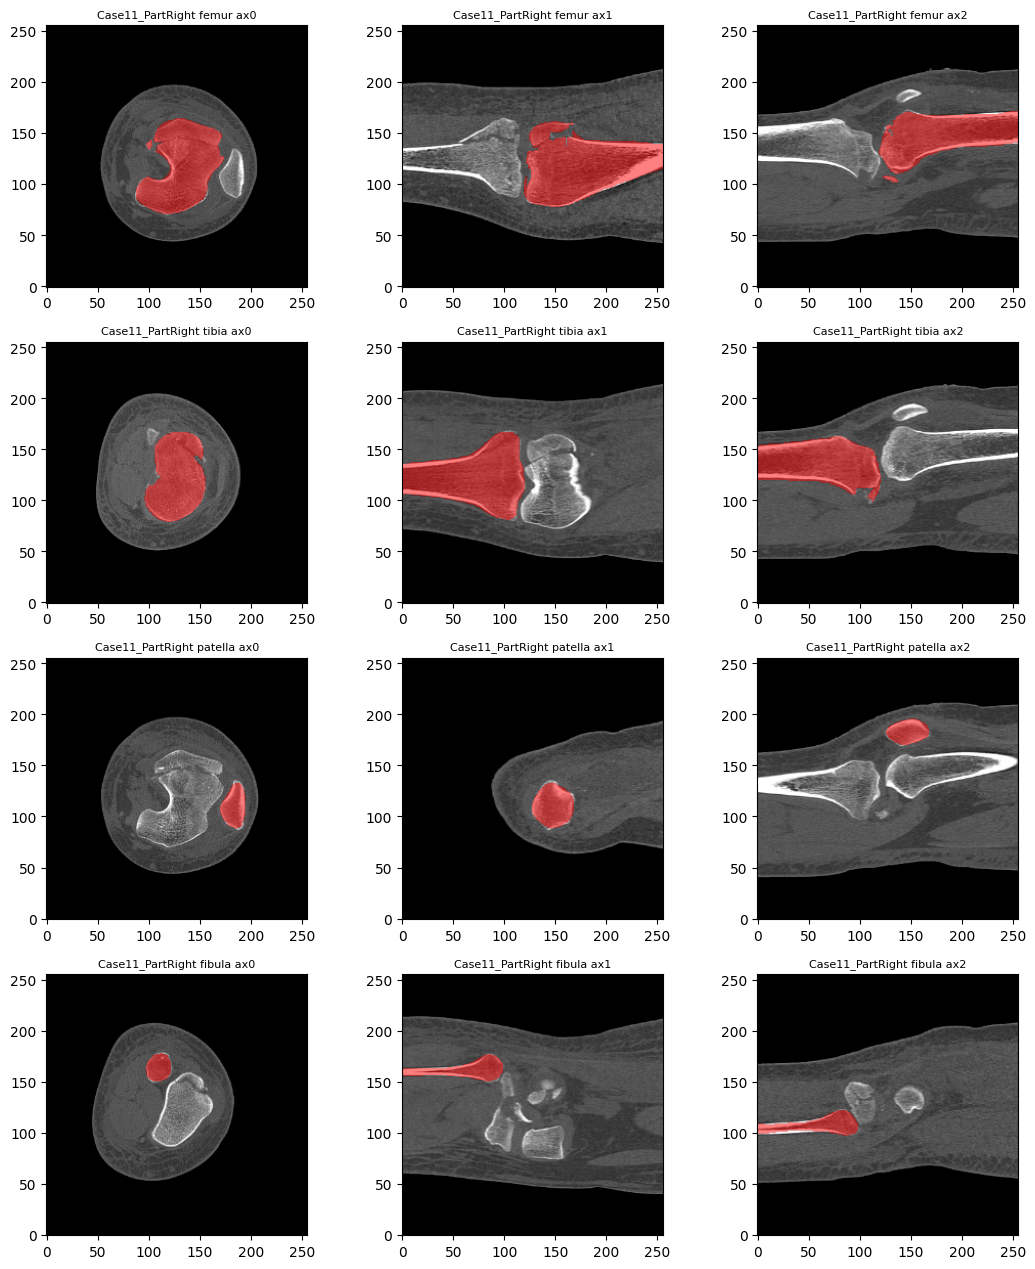

In [8]:
key = sorted(cases)[0]
ct, gt = build_bone_gt(key, cases[key])
ctf = ct["ct_final"]
for bone in BONES:
    print(key, bone, "voxels:", int(gt[bone].sum()))
    assert gt[bone].sum() > 300, f"{bone} mask implausibly small"

fig, ax = plt.subplots(len(BONES), 3, figsize=(11, 3.2 * len(BONES)))
for r, bone in enumerate(BONES):
    mask = gt[bone]
    for a, axis in enumerate([0, 1, 2]):
        s = mask.sum(axis=tuple(i for i in range(3) if i != axis)).argmax()
        ax[r, a].imshow(np.take(ctf, s, axis=axis).T, cmap="gray", origin="lower")
        ms = np.take(mask, s, axis=axis)
        ax[r, a].imshow(np.ma.masked_where(ms.T == 0, ms.T), cmap="autumn", alpha=0.5, origin="lower")
        ax[r, a].set_title(f"{key} {bone} ax{axis}", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_ROOT / f"_spotcheck_{key}.png", dpi=110); plt.show()

In [9]:
import pandas as pd
rows = []
for key, bone_map in sorted(cases.items()):
    ct, gt = build_bone_gt(key, bone_map)
    d = dice(ct["ct_final"] > 0.4, load_grid_zyx(PREDRR / f"{key}.nii.gz") > 0.4)
    case_dir = OUT_ROOT / key; case_dir.mkdir(parents=True, exist_ok=True)
    for bone in BONES:
        mask = gt[bone]
        save_grid_nii(mask, key, case_dir / f"{key}_{bone}.nii.gz")
        rows.append(dict(key=key, bone=bone, voxels=int(mask.sum()),
                         ct_replay_dice=round(float(d), 4), source_stl=bone_map[bone].name))
    print(f"{key}: ct-replay Dice {d:.4f}  bones " + " ".join(f"{b}={int(gt[b].sum())}" for b in BONES))
meta = pd.DataFrame(rows); meta.to_csv(OUT_ROOT / "gt_per_bone_metadata.csv", index=False)
meta.groupby("key").agg(min_voxels=("voxels", "min"), ct_dice=("ct_replay_dice", "first"))

Case11_PartRight: ct-replay Dice 1.0000  bones femur=298259 tibia=231064 patella=22206 fibula=17346


Case12_PartRight: ct-replay Dice 1.0000  bones femur=374495 tibia=437949 patella=47276 fibula=60501


Case13_PartRight: ct-replay Dice 1.0000  bones femur=309995 tibia=277661 patella=28859 fibula=27934


Case16_PartRight: ct-replay Dice 1.0000  bones femur=337761 tibia=314387 patella=33967 fibula=32072


Case1_PartLeft: ct-replay Dice 1.0000  bones femur=313730 tibia=284854 patella=28157 fibula=18427


...

Case5_PartRight: ct-replay Dice 1.0000  bones femur=393482 tibia=399831 patella=40236 fibula=41625


Case6_PartRight: ct-replay Dice 1.0000  bones femur=317121 tibia=331538 patella=45688 fibula=34681


Case7_PartRight: ct-replay Dice 1.0000  bones femur=232926 tibia=158493 patella=17539 fibula=14814


Case9_PartRight: ct-replay Dice 1.0000  bones femur=420084 tibia=370318 patella=40084 fibula=21120


,min_voxels,ct_dice
key,,
Case11_PartRight,17346,1.0
Case12_PartRight,47276,1.0
Case13_PartRight,27934,1.0
Case16_PartRight,32072,1.0
Case1_PartLeft,18427,1.0
Case2_PartLeft,26967,1.0
Case3_PartLeft,24511,1.0
Case5_PartRight,40236,1.0
Case6_PartRight,34681,1.0


In [10]:
assert (meta.groupby("key").size() == 4).all(), "every case must have 4 bone files"
assert (meta.voxels > 300).all(), f"empty/tiny masks:\n{meta[meta.voxels <= 300]}"
assert (meta.ct_replay_dice >= 0.99).all(), f"CT replay failed for:\n{meta[meta.ct_replay_dice < 0.99]}"
nfiles = sum(1 for _ in OUT_ROOT.rglob('*.nii.gz'))
assert nfiles == 4 * len(cases), f"expected {4*len(cases)} files, found {nfiles}"
print("OK:", len(cases), "cases x4 bones; all CT-replays >=0.99; ", nfiles, "nii.gz written")

OK: 11 cases x4 bones; all CT-replays >=0.99;  44 nii.gz written


## Alignment validation gate

Alignment is already guaranteed by construction (the CT-replay Dice = 1.0 for every case). These
cells provide the cohort-level confirmation: per-case GT-union vs predrr bone-mask Dice, and AP/LAT
MIP overlays of the GT union on the predrr silhouette. The union-vs-predrr Dice is expected to be
high but < 1.0 (predrr thresholds marrow/soft bone the clean STL surface segmentation excludes); a
case far below the cohort median would indicate a per-case frame problem to investigate.

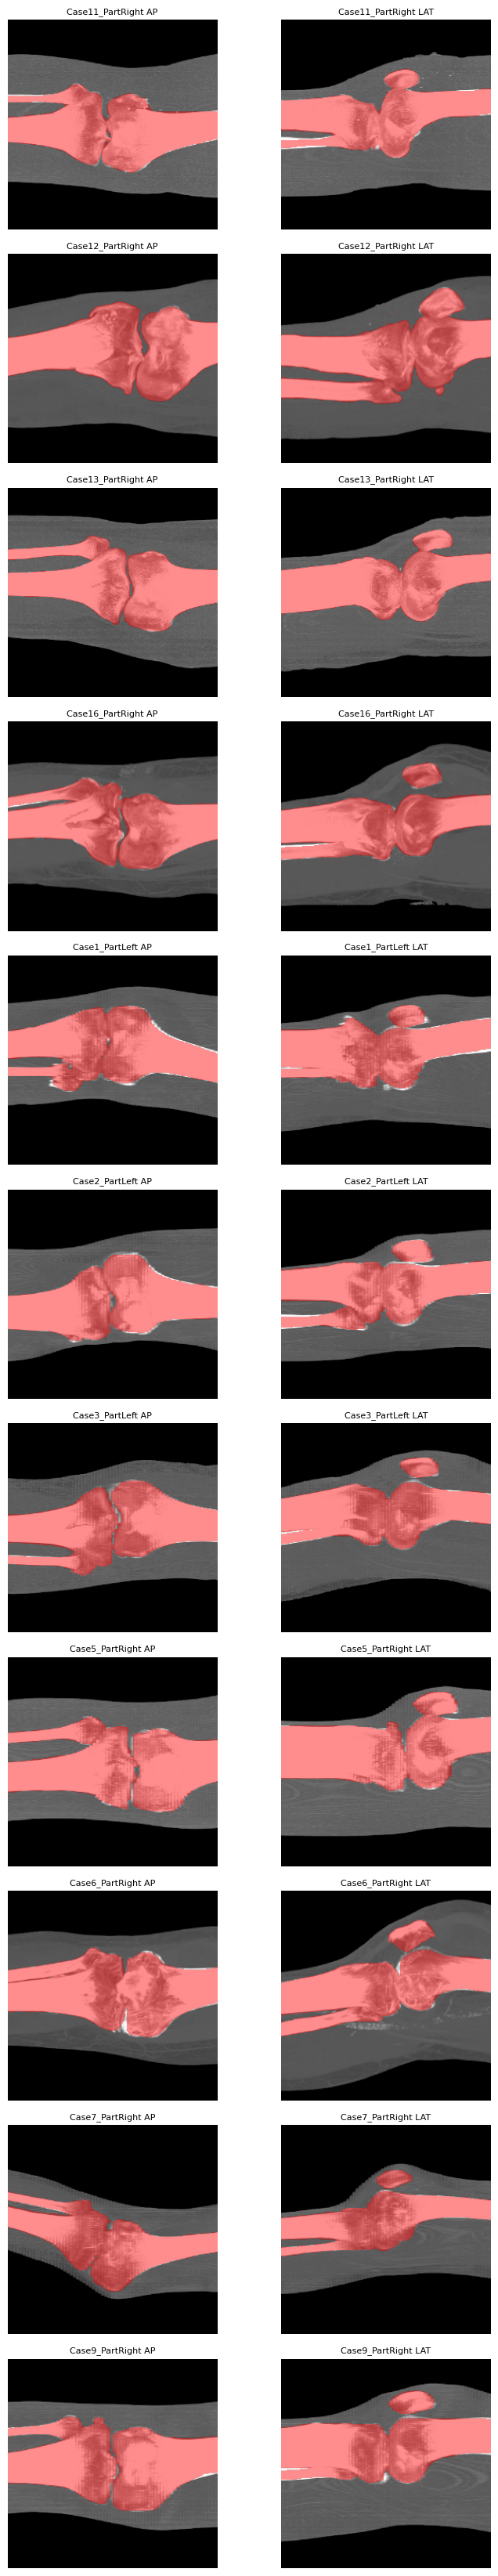

cohort median union-Dice: 0.712 | suspect cases: none


,key,union_voxels,dice_union_vs_predrr
0,Case11_PartRight,568807,0.8204
1,Case12_PartRight,920081,0.7120
2,Case13_PartRight,644387,0.7597
3,Case16_PartRight,718086,0.5839
4,Case1_PartLeft,644958,0.6642
5,Case2_PartLeft,677433,0.8064
6,Case3_PartLeft,666019,0.7111
7,Case5_PartRight,875163,0.7448
8,Case6_PartRight,728949,0.6287
9,Case7_PartRight,423715,0.6414


In [11]:
# --- per-case GT-union vs predrr bone-mask Dice ---
ar = []
for key in sorted(cases):
    union = np.zeros((TARGET_SIZE,) * 3, bool)
    for bone in BONES:
        union |= load_grid_zyx(OUT_ROOT / key / f"{key}_{bone}.nii.gz") > 0
    pred_bone = load_grid_zyx(PREDRR / f"{key}.nii.gz") > 0.4
    ar.append(dict(key=key, union_voxels=int(union.sum()),
                   dice_union_vs_predrr=round(float(dice(union, pred_bone)), 4)))
align = pd.DataFrame(ar); align.to_csv(OUT_ROOT / "gt_per_bone_alignment.csv", index=False)

# --- AP/LAT MIP overlay grid (GT union over predrr silhouette) ---
n = len(cases); fig, ax = plt.subplots(n, 2, figsize=(8, 3.0 * n))
for r, key in enumerate(sorted(cases)):
    ctf = load_grid_zyx(PREDRR / f"{key}.nii.gz")   # predrr == ct_final (Dice 1.0); avoids DICOM reload
    union = np.zeros((TARGET_SIZE,) * 3, bool)
    for bone in BONES:
        union |= load_grid_zyx(OUT_ROOT / key / f"{key}_{bone}.nii.gz") > 0
    for c, axis, name in [(0, 1, "AP"), (1, 2, "LAT")]:
        ax[r, c].imshow(ctf.max(axis=axis).T, cmap="gray", origin="lower")
        u = union.max(axis=axis)
        ax[r, c].imshow(np.ma.masked_where(u.T == 0, u.T), cmap="autumn", alpha=0.45, origin="lower")
        ax[r, c].set_title(f"{key} {name}", fontsize=8); ax[r, c].axis("off")
plt.tight_layout(); plt.savefig(OUT_ROOT / "alignment_grid.png", dpi=110); plt.show()

med = align.dice_union_vs_predrr.median()
suspect = align[align.dice_union_vs_predrr < med - 0.15]
print("cohort median union-Dice:", round(med, 3), "| suspect cases:", list(suspect.key) or "none")
align